<a href="https://colab.research.google.com/github/monica0130/Build-A-Quiz-App-With-HTML-CSS-and-JavaScript/blob/master/Copy_of_Wind_Energy_Efficiency.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Problem Statement : A wind farmer wants to monitor and predict the efficiency
# of his wind Turbines using sensor data collected from the turbines

In [ ]:
# Dataset link -> https://drive.google.com/file/d/1pGU0UG5dyvEviYbHVBb4slqJSXmw19V4/view

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/train (1).csv')

In [ ]:
df

,timestamp,active_power_calculated_by_converter,active_power_raw,ambient_temperature,generator_speed,generator_winding_temp_max,grid_power10min_average,nc1_inside_temp,nacelle_temp,reactice_power_calculated_by_converter,reactive_power,wind_direction_raw,wind_speed_raw,wind_speed_turbulence,turbine_id,Target
0,2021-02-19 20:18:00,816.636759,834.917206,31.694380,1159.616602,65.954214,917.897085,31.881972,31.504713,141.457644,165.501518,280.864782,7.057000,0.544082,Turbine_108,47.582787
1,2021-04-27 04:55:00,419.107829,421.050873,12.894948,928.747996,59.571319,445.554250,32.423705,32.755770,89.186457,113.835236,299.552460,5.474937,0.469031,Turbine_18,46.070328
2,2021-01-25 06:26:00,1303.530558,1337.566142,16.648388,1201.219775,61.270498,1364.716003,11.446849,18.332985,230.622309,281.452253,84.960106,8.092457,0.622318,Turbine_105,39.989236
3,2021-10-30 03:47:00,61.494872,53.481008,28.388141,769.806122,40.674348,14.324897,34.253204,32.662889,66.211015,75.017531,87.261119,4.071032,0.760719,Turbine_15,46.056587
4,2021-03-15 00:39:00,593.514364,611.659108,31.519527,1046.916768,64.341763,599.020172,32.405586,31.466387,137.163938,160.202421,313.724818,6.357943,0.346068,Turbine_01,54.346095
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
909599,2021-04-25 19:12:00,929.101908,948.441905,32.736076,1187.303192,83.187140,1343.320577,32.291391,35.152280,152.216446,191.088800,189.901812,7.155343,1.028960,Turbine_13,50.768675
909600,2021-02-20 17:37:00,100.730526,88.694599,30.540500,770.245593,56.235497,177.620552,30.434302,29.932141,85.353107,96.621675,93.417590,4.121607,0.595874,Turbine_158,44.234821
909601,2021-10-22 14:18:00,1120.915965,1165.016907,30.901129,1170.456860,62.942943,873.414622,30.491818,33.085164,42.820210,74.111173,230.988398,8.551669,0.951241,Turbine_15,46.942486
909602,2021-02-08 22:03:00,123.444564,116.066919,32.697933,770.190796,57.245207,95.865704,32.338824,31.525384,86.549094,97.470984,65.408801,4.324064,0.247335,Turbine_97,46.392221


In [ ]:
# Import and then confirm

In [ ]:
df.head()

,timestamp,active_power_calculated_by_converter,active_power_raw,ambient_temperature,generator_speed,generator_winding_temp_max,grid_power10min_average,nc1_inside_temp,nacelle_temp,reactice_power_calculated_by_converter,reactive_power,wind_direction_raw,wind_speed_raw,wind_speed_turbulence,turbine_id,Target
0,2021-02-19 20:18:00,816.636759,834.917206,31.694380,1159.616602,65.954214,917.897085,31.881972,31.504713,141.457644,165.501518,280.864782,7.057000,0.544082,Turbine_108,47.582787
1,2021-04-27 04:55:00,419.107829,421.050873,12.894948,928.747996,59.571319,445.554250,32.423705,32.755770,89.186457,113.835236,299.552460,5.474937,0.469031,Turbine_18,46.070328
2,2021-01-25 06:26:00,1303.530558,1337.566142,16.648388,1201.219775,61.270498,1364.716003,11.446849,18.332985,230.622309,281.452253,84.960106,8.092457,0.622318,Turbine_105,39.989236
3,2021-10-30 03:47:00,61.494872,53.481008,28.388141,769.806122,40.674348,14.324897,34.253204,32.662889,66.211015,75.017531,87.261119,4.071032,0.760719,Turbine_15,46.056587
4,2021-03-15 00:39:00,593.514364,611.659108,31.519527,1046.916768,64.341763,599.020172,32.405586,31.466387,137.163938,160.202421,313.724818,6.357943,0.346068,Turbine_01,54.346095


In [ ]:
df.tail()

,timestamp,active_power_calculated_by_converter,active_power_raw,ambient_temperature,generator_speed,generator_winding_temp_max,grid_power10min_average,nc1_inside_temp,nacelle_temp,reactice_power_calculated_by_converter,reactive_power,wind_direction_raw,wind_speed_raw,wind_speed_turbulence,turbine_id,Target
909599,2021-04-25 19:12:00,929.101908,948.441905,32.736076,1187.303192,83.187140,1343.320577,32.291391,35.152280,152.216446,191.088800,189.901812,7.155343,1.028960,Turbine_13,50.768675
909600,2021-02-20 17:37:00,100.730526,88.694599,30.540500,770.245593,56.235497,177.620552,30.434302,29.932141,85.353107,96.621675,93.417590,4.121607,0.595874,Turbine_158,44.234821
909601,2021-10-22 14:18:00,1120.915965,1165.016907,30.901129,1170.456860,62.942943,873.414622,30.491818,33.085164,42.820210,74.111173,230.988398,8.551669,0.951241,Turbine_15,46.942486
909602,2021-02-08 22:03:00,123.444564,116.066919,32.697933,770.190796,57.245207,95.865704,32.338824,31.525384,86.549094,97.470984,65.408801,4.324064,0.247335,Turbine_97,46.392221
909603,2021-04-09 14:28:00,4.843147,10.779734,19.452520,736.601664,60.603885,78.559767,30.798932,38.252200,2.763231,1.320198,11.127739,2.017444,0.963029,Turbine_105,48.902180


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 909604 entries, 0 to 909603
Data columns (total 16 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   timestamp                               909604 non-null  object 
 1   active_power_calculated_by_converter    909604 non-null  float64
 2   active_power_raw                        909604 non-null  float64
 3   ambient_temperature                     909604 non-null  float64
 4   generator_speed                         909604 non-null  float64
 5   generator_winding_temp_max              909604 non-null  float64
 6   grid_power10min_average                 909604 non-null  float64
 7   nc1_inside_temp                         909604 non-null  float64
 8   nacelle_temp                            909604 non-null  float64
 9   reactice_power_calculated_by_converter  909604 non-null  float64
 10  reactive_power                          9096

In [ ]:
df.isnull().sum()

,0
timestamp,0
active_power_calculated_by_converter,0
active_power_raw,0
ambient_temperature,0
generator_speed,0
generator_winding_temp_max,0
grid_power10min_average,0
nc1_inside_temp,0
nacelle_temp,0
reactice_power_calculated_by_converter,0


In [ ]:
df.duplicated().sum()

np.int64(0)

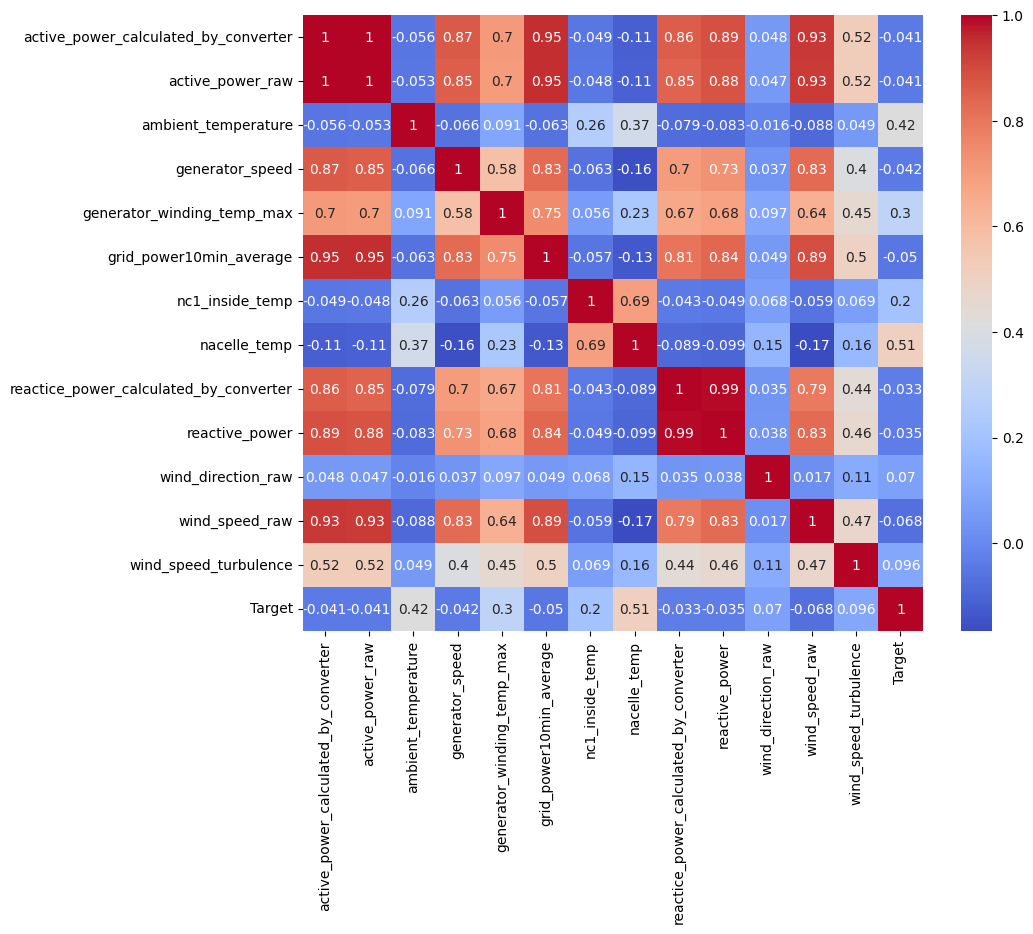

In [ ]:
# I want to Multicollinearity - Heatmap

plt.figure(figsize =(10,8))
sns.heatmap(df.corr(numeric_only=True),annot =True,cmap ="coolwarm")
plt.show()

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
col_list = []
for i in df.columns:
  if (df[i].dtypes == "float64" and i!= "Target"):
    col_list.append(i)

col_list



['active_power_calculated_by_converter',
 'active_power_raw',
 'ambient_temperature',
 'generator_speed',
 'generator_winding_temp_max',
 'grid_power10min_average',
 'nc1_inside_temp',
 'nacelle_temp',
 'reactice_power_calculated_by_converter',
 'reactive_power',
 'wind_direction_raw',
 'wind_speed_raw',
 'wind_speed_turbulence']

In [ ]:
x = df[col_list]
x

,active_power_calculated_by_converter,active_power_raw,ambient_temperature,generator_speed,generator_winding_temp_max,grid_power10min_average,nc1_inside_temp,nacelle_temp,reactice_power_calculated_by_converter,reactive_power,wind_direction_raw,wind_speed_raw,wind_speed_turbulence
0,816.636759,834.917206,31.694380,1159.616602,65.954214,917.897085,31.881972,31.504713,141.457644,165.501518,280.864782,7.057000,0.544082
1,419.107829,421.050873,12.894948,928.747996,59.571319,445.554250,32.423705,32.755770,89.186457,113.835236,299.552460,5.474937,0.469031
2,1303.530558,1337.566142,16.648388,1201.219775,61.270498,1364.716003,11.446849,18.332985,230.622309,281.452253,84.960106,8.092457,0.622318
3,61.494872,53.481008,28.388141,769.806122,40.674348,14.324897,34.253204,32.662889,66.211015,75.017531,87.261119,4.071032,0.760719
4,593.514364,611.659108,31.519527,1046.916768,64.341763,599.020172,32.405586,31.466387,137.163938,160.202421,313.724818,6.357943,0.346068
...,...,...,...,...,...,...,...,...,...,...,...,...,...
909599,929.101908,948.441905,32.736076,1187.303192,83.187140,1343.320577,32.291391,35.152280,152.216446,191.088800,189.901812,7.155343,1.028960
909600,100.730526,88.694599,30.540500,770.245593,56.235497,177.620552,30.434302,29.932141,85.353107,96.621675,93.417590,4.121607,0.595874
909601,1120.915965,1165.016907,30.901129,1170.456860,62.942943,873.414622,30.491818,33.085164,42.820210,74.111173,230.988398,8.551669,0.951241
909602,123.444564,116.066919,32.697933,770.190796,57.245207,95.865704,32.338824,31.525384,86.549094,97.470984,65.408801,4.324064,0.247335


In [ ]:
vif_data = pd.DataFrame()
vif_data['column_name'] = x.columns
vif_data['vif_score'] = [variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
print(vif_data)

                               column_name   vif_score
0     active_power_calculated_by_converter  398.566300
1                         active_power_raw  361.707774
2                      ambient_temperature   13.134672
3                          generator_speed   75.538793
4               generator_winding_temp_max  127.768808
5                  grid_power10min_average   30.870003
6                          nc1_inside_temp  140.004469
7                             nacelle_temp  255.939425
8   reactice_power_calculated_by_converter  328.529943
9                           reactive_power  427.087748
10                      wind_direction_raw    4.824868
11                          wind_speed_raw   74.328616
12                   wind_speed_turbulence    7.825816


In [ ]:
df = df.drop(columns='reactive_power',axis = 1)

In [ ]:
col_list = []
for i in df.columns:
  if (df[i].dtypes == "float64" and i!= "Target"):
    col_list.append(i)

x = df[col_list]

vif_data = pd.DataFrame()
vif_data['column_name'] = x.columns
vif_data['vif_score'] = [variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
print(vif_data)

                               column_name   vif_score
0     active_power_calculated_by_converter  395.268258
1                         active_power_raw  350.365548
2                      ambient_temperature   13.104176
3                          generator_speed   74.194993
4               generator_winding_temp_max  127.029415
5                  grid_power10min_average   30.867511
6                          nc1_inside_temp  140.004381
7                             nacelle_temp  255.874458
8   reactice_power_calculated_by_converter   13.312498
9                       wind_direction_raw    4.821565
10                          wind_speed_raw   69.736803
11                   wind_speed_turbulence    7.825603


In [ ]:
df = df.drop(['active_power_calculated_by_converter'],axis = 1)

In [ ]:
col_list = []
for i in df.columns:
  if (df[i].dtypes == "float64" and i!= "Target"):
    col_list.append(i)

x = df[col_list]

vif_data = pd.DataFrame()
vif_data['column_name'] = x.columns
vif_data['vif_score'] = [variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
print(vif_data)

                               column_name   vif_score
0                         active_power_raw   40.939031
1                      ambient_temperature   13.102296
2                          generator_speed   70.251025
3               generator_winding_temp_max  126.042200
4                  grid_power10min_average   30.190083
5                          nc1_inside_temp  139.485541
6                             nacelle_temp  255.542439
7   reactice_power_calculated_by_converter   11.432388
8                       wind_direction_raw    4.821516
9                           wind_speed_raw   69.700467
10                   wind_speed_turbulence    7.822965


In [ ]:
df = df.drop(['nacelle_temp'],axis = 1)

In [ ]:
col_list = []
for i in df.columns:
  if (df[i].dtypes == "float64" and i!= "Target"):
    col_list.append(i)

x = df[col_list]

vif_data = pd.DataFrame()
vif_data['column_name'] = x.columns
vif_data['vif_score'] = [variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
print(vif_data)

                              column_name  vif_score
0                        active_power_raw  40.386321
1                     ambient_temperature  12.644618
2                         generator_speed  70.085140
3              generator_winding_temp_max  76.623885
4                 grid_power10min_average  26.481121
5                         nc1_inside_temp  56.975296
6  reactice_power_calculated_by_converter  11.338216
7                      wind_direction_raw   4.750110
8                          wind_speed_raw  69.060440
9                   wind_speed_turbulence   7.477829


In [ ]:
df = df.drop(['generator_winding_temp_max'],axis = 1)

In [ ]:
col_list = []
for i in df.columns:
  if (df[i].dtypes == "float64" and i!= "Target"):
    col_list.append(i)

x = df[col_list]

vif_data = pd.DataFrame()
vif_data['column_name'] = x.columns
vif_data['vif_score'] = [variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
print(vif_data)

                              column_name  vif_score
0                        active_power_raw  36.548322
1                     ambient_temperature  11.935077
2                         generator_speed  64.481775
3                 grid_power10min_average  23.620350
4                         nc1_inside_temp  46.515458
5  reactice_power_calculated_by_converter  10.627115
6                      wind_direction_raw   4.666287
7                          wind_speed_raw  67.601772
8                   wind_speed_turbulence   7.300019


In [ ]:
df = df.drop(['wind_speed_raw'],axis = 1)

In [ ]:
col_list = []
for i in df.columns:
  if (df[i].dtypes == "float64" and i!= "Target"):
    col_list.append(i)

x = df[col_list]

vif_data = pd.DataFrame()
vif_data['column_name'] = x.columns
vif_data['vif_score'] = [variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
print(vif_data)

                              column_name  vif_score
0                        active_power_raw  31.140023
1                     ambient_temperature  11.913998
2                         generator_speed  49.190837
3                 grid_power10min_average  23.587148
4                         nc1_inside_temp  42.458906
5  reactice_power_calculated_by_converter  10.575211
6                      wind_direction_raw   4.661972
7                   wind_speed_turbulence   7.292047


In [ ]:
df = df.drop(['generator_speed'],axis = 1)

In [ ]:
col_list = []
for i in df.columns:
  if (df[i].dtypes == "float64" and i!= "Target"):
    col_list.append(i)

x = df[col_list]

vif_data = pd.DataFrame()
vif_data['column_name'] = x.columns
vif_data['vif_score'] = [variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
print(vif_data)

                              column_name  vif_score
0                        active_power_raw  29.136233
1                     ambient_temperature  11.831492
2                 grid_power10min_average  23.238285
3                         nc1_inside_temp  18.939003
4  reactice_power_calculated_by_converter  10.572131
5                      wind_direction_raw   4.613515
6                   wind_speed_turbulence   7.290612


In [ ]:
df = df.drop(['active_power_raw'],axis = 1)

In [ ]:
col_list = []
for i in df.columns:
  if (df[i].dtypes == "float64" and i!= "Target"):
    col_list.append(i)

x = df[col_list]

vif_data = pd.DataFrame()
vif_data['column_name'] = x.columns
vif_data['vif_score'] = [variance_inflation_factor(x.values,i) for i in range(len(x.columns))]
print(vif_data)

                              column_name  vif_score
0                     ambient_temperature  11.825219
1                 grid_power10min_average   6.984664
2                         nc1_inside_temp  18.679671
3  reactice_power_calculated_by_converter   8.686431
4                      wind_direction_raw   4.612084
5                   wind_speed_turbulence   7.127731


In [ ]:
col_list = []              # Use a for loop for the same
for col in df.columns:
    if df[col].dtype == "float64" and col != "Target":
        col_list.append(col)
threshold = 5
while True:
    X = df[col_list]
    vif = []
    for i in range(len(X.columns)):
        vif.append(variance_inflation_factor(X.values, i))
    max_vif = max(vif)
    if max_vif <= threshold:
        break
    remove_col = X.columns[vif.index(max_vif)]
    print(f"{remove_col} (VIF = {max_vif:.2f})")
    col_list.remove(remove_col)
print(col_list)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 909604 entries, 0 to 909603
Data columns (total 9 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   timestamp                               909604 non-null  object 
 1   ambient_temperature                     909604 non-null  float64
 2   grid_power10min_average                 909604 non-null  float64
 3   nc1_inside_temp                         909604 non-null  float64
 4   reactice_power_calculated_by_converter  909604 non-null  float64
 5   wind_direction_raw                      909604 non-null  float64
 6   wind_speed_turbulence                   909604 non-null  float64
 7   turbine_id                              909604 non-null  object 
 8   Target                                  909604 non-null  float64
dtypes: float64(7), object(2)
memory usage: 62.5+ MB


In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 909604 entries, 0 to 909603
Data columns (total 9 columns):
 #   Column                                  Non-Null Count   Dtype         
---  ------                                  --------------   -----         
 0   timestamp                               909604 non-null  datetime64[ns]
 1   ambient_temperature                     909604 non-null  float64       
 2   grid_power10min_average                 909604 non-null  float64       
 3   nc1_inside_temp                         909604 non-null  float64       
 4   reactice_power_calculated_by_converter  909604 non-null  float64       
 5   wind_direction_raw                      909604 non-null  float64       
 6   wind_speed_turbulence                   909604 non-null  float64       
 7   turbine_id                              909604 non-null  object        
 8   Target                                  909604 non-null  float64       
dtypes: datetime64[ns](1), float64(7), obje

In [ ]:
df['timestamp']

,timestamp
0,2021-02-19 20:18:00
1,2021-04-27 04:55:00
2,2021-01-25 06:26:00
3,2021-10-30 03:47:00
4,2021-03-15 00:39:00
...,...
909599,2021-04-25 19:12:00
909600,2021-02-20 17:37:00
909601,2021-10-22 14:18:00
909602,2021-02-08 22:03:00


In [ ]:
df['hour'] = df['timestamp'].dt.hour
df['month'] = df['timestamp'].dt.month

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 909604 entries, 0 to 909603
Data columns (total 11 columns):
 #   Column                                  Non-Null Count   Dtype         
---  ------                                  --------------   -----         
 0   timestamp                               909604 non-null  datetime64[ns]
 1   ambient_temperature                     909604 non-null  float64       
 2   grid_power10min_average                 909604 non-null  float64       
 3   nc1_inside_temp                         909604 non-null  float64       
 4   reactice_power_calculated_by_converter  909604 non-null  float64       
 5   wind_direction_raw                      909604 non-null  float64       
 6   wind_speed_turbulence                   909604 non-null  float64       
 7   turbine_id                              909604 non-null  object        
 8   Target                                  909604 non-null  float64       
 9   hour                                 

In [ ]:
df['hour']

,hour
0,20
1,4
2,6
3,3
4,0
...,...
909599,19
909600,17
909601,14
909602,22


In [ ]:
df['month'].unique()

array([ 2,  4,  1, 10,  3,  5,  8,  7,  6,  9, 11, 12], dtype=int32)

In [ ]:
# perfrom Label Encoding

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [ ]:
df['turbine_id'] = le.fit_transform(df['turbine_id'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 909604 entries, 0 to 909603
Data columns (total 11 columns):
 #   Column                                  Non-Null Count   Dtype         
---  ------                                  --------------   -----         
 0   timestamp                               909604 non-null  datetime64[ns]
 1   ambient_temperature                     909604 non-null  float64       
 2   grid_power10min_average                 909604 non-null  float64       
 3   nc1_inside_temp                         909604 non-null  float64       
 4   reactice_power_calculated_by_converter  909604 non-null  float64       
 5   wind_direction_raw                      909604 non-null  float64       
 6   wind_speed_turbulence                   909604 non-null  float64       
 7   turbine_id                              909604 non-null  int64         
 8   Target                                  909604 non-null  float64       
 9   hour                                 

In [ ]:
# Model Building

In [ ]:
# Linear Regression

In [ ]:
# split data into x and y

x = df.drop(['Target','timestamp'],axis = 1)
y = df['Target']

In [ ]:
x

,ambient_temperature,grid_power10min_average,nc1_inside_temp,reactice_power_calculated_by_converter,wind_direction_raw,wind_speed_turbulence,turbine_id,hour,month
0,31.694380,917.897085,31.881972,141.457644,280.864782,0.544082,4,20,2
1,12.894948,445.554250,32.423705,89.186457,299.552460,0.469031,12,4,4
2,16.648388,1364.716003,11.446849,230.622309,84.960106,0.622318,3,6,1
3,28.388141,14.324897,34.253204,66.211015,87.261119,0.760719,10,3,10
4,31.519527,599.020172,32.405586,137.163938,313.724818,0.346068,0,0,3
...,...,...,...,...,...,...,...,...,...
909599,32.736076,1343.320577,32.291391,152.216446,189.901812,1.028960,7,19,4
909600,30.540500,177.620552,30.434302,85.353107,93.417590,0.595874,11,17,2
909601,30.901129,873.414622,30.491818,42.820210,230.988398,0.951241,10,14,10
909602,32.697933,95.865704,32.338824,86.549094,65.408801,0.247335,15,22,2


In [ ]:
y

,Target
0,47.582787
1,46.070328
2,39.989236
3,46.056587
4,54.346095
...,...
909599,50.768675
909600,44.234821
909601,46.942486
909602,46.392221


In [ ]:
# perfrom train-test split

from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state = 42)

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
y_pred

array([44.9796377 , 47.38418069, 45.77310957, ..., 46.14366414,
       44.12951723, 46.1635491 ])

In [ ]:
from sklearn.metrics import *


In [ ]:
r2_score = r2_score(y_test,y_pred)

In [ ]:
r2_score

0.238578226236408

In [ ]:
from sklearn.tree import DecisionTreeRegressor

In [ ]:
model1 = DecisionTreeRegressor(random_state = 42)

In [ ]:
model1.fit(x_train,y_train)

DecisionTreeRegressor(random_state=42)

In [ ]:
y_pred1 = model1.predict(x_test)

In [ ]:
from sklearn.metrics import *


In [ ]:
score1 = r2_score(y_test,y_pred1)

In [ ]:
score1

0.8707155254993177

In [ ]:
# Try with Random Forest
# and Hyperparamter Tuning

# To reach to a conclusion about which model has the most effciency


# Add here Parameters like MAE , MSE , RMSE

# Feature Importance

In [ ]:
# Create a Modal Comparison Table

#